In [2]:
import tensorflow as tf 
from keras import layers, models
from keras.layers import Dense, Flatten, Conv2D
from keras.models import Sequential 
import numpy as np 
import matplotlib.pyplot as plt 
from keras.datasets import mnist 
import pandas as pd 

In [3]:
(train_x , train_y), (test_x, test_y) = mnist.load_data()

In [4]:
print(train_x.shape)
print(train_y.shape) 
print(test_x.shape)
print(test_y.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


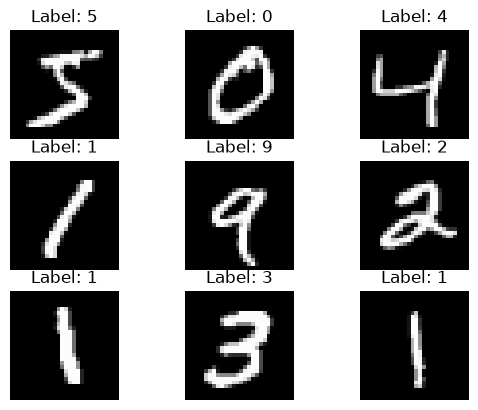

In [5]:
for i in range(9): 
       plt.subplot(3,3,i+1) 
       plt.imshow(train_x[i], cmap='gray') 
       plt.title('Label: {}'.format(train_y[i])) 
       plt.axis('off')

In [6]:
model= tf.keras.models.Sequential(
       [tf.keras.layers.Input((28,28)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')]
        
) 

In [7]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        12,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,002 (50.79 KB)

 Trainable params: 13,002 (50.79 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.fit(train_x, train_y, epochs=25, batch_size=32, validation_split=0.2)

Epoch 1/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.1138 - loss: 2.9913 - val_accuracy: 0.1184 - val_loss: 2.2769
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2174 - loss: 2.0881 - val_accuracy: 0.3461 - val_loss: 1.7491
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.4105 - loss: 1.5533 - val_accuracy: 0.4722 - val_loss: 1.3584
Epoch 4/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5172 - loss: 1.2560 - val_accuracy: 0.5709 - val_loss: 1.0865
Epoch 5/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6071 - loss: 1.0485 - val_accuracy: 0.6281 - val_loss: 0.9833
Epoch 6/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7126 - loss: 0.8857 - val_accuracy: 0.7313 - val_loss: 0.8338
Epoch 7/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7575 - loss: 0.7589 - val_accuracy: 0.8008 - val_loss: 0.6666
Epoch 8/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8147 - loss: 0.6503 - 

In [10]:
model.evaluate(test_x, test_y)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8742 - loss: 0.4649


[0.46486973762512207, 0.8741999864578247]

C:\Users\Shuvo\AppData\Roaming\Python\Python313\site-packages\shap\explainers\_deep\deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
C:\Users\Shuvo\AppData\Roaming\Python\Python313\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(100, 28, 28))']
  warnings.warn(msg)
C:\Users\Shuvo\AppData\Roaming\Python\Python313\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(200, 28, 28))']
  warnings.warn(msg)
C:\Users\Shuvo\AppData\Roaming\Python\Python313\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected s

SHAP values computed successfully!
Visualizing SHAP explanations (Red = increases probability, Blue = decreases probability):


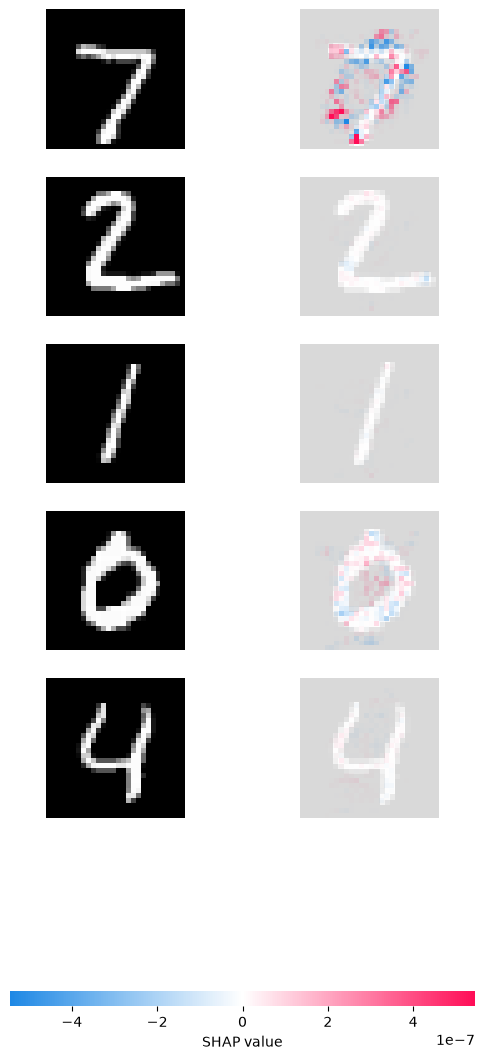

In [11]:
# =========================================================
# 1. SHAP (SHapley Additive exPlanations)
# =========================================================
import shap

# Select background samples for baseline expectation
background = train_x[:100].astype(np.float32)

# Select test samples to explain (e.g. first 5 digits)
num_test_samples = 5
sample_test_images = test_x[:num_test_samples].astype(np.float32)

# Initialize DeepExplainer
explainer_shap = shap.DeepExplainer(model, background)
shap_values = explainer_shap.shap_values(sample_test_images)

print("SHAP values computed successfully!")
print("Visualizing SHAP explanations (Red = increases probability, Blue = decreases probability):")
# Visualizing SHAP explanations across all 10 output classes
shap.image_plot(shap_values, sample_test_images)


Explaining Sample #0
True Label:      7
Predicted Label: 7 (Confidence: 99.54%)


100%|██████████| 1000/1000 [00:07<00:00, 127.97it/s]


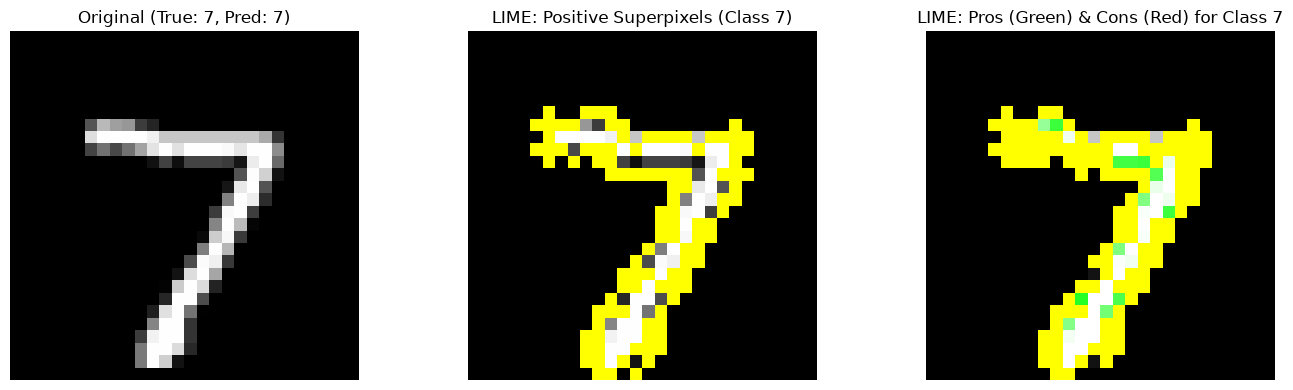

In [12]:
# =========================================================
# 2. LIME (Local Interpretable Model-agnostic Explanations)
# =========================================================
from lime import lime_image
from skimage.segmentation import mark_boundaries

# Initialize LIME Image Explainer
explainer_lime = lime_image.LimeImageExplainer()

# Prediction function for LIME: converts RGB perturbations back to grayscale
def lime_predict(images):
    gray_images = images[:, :, :, 0].astype(np.float32)
    return model.predict(gray_images, verbose=0)

# Choose a test digit to explain
sample_index = 0
sample_img = test_x[sample_index].astype(np.float32)
true_label = test_y[sample_index]

pred_probs = model.predict(sample_img[np.newaxis, ...], verbose=0)[0]
predicted_label = int(np.argmax(pred_probs))

print(f"Explaining Sample #{sample_index}")
print(f"True Label:      {true_label}")
print(f"Predicted Label: {predicted_label} (Confidence: {pred_probs[predicted_label]:.2%})")

# Convert grayscale image to 3-channel RGB for LIME segmentation
sample_img_rgb = np.stack([sample_img] * 3, axis=-1)

# Generate explanation
explanation = explainer_lime.explain_instance(
    sample_img_rgb.astype('double'),
    lime_predict,
    top_labels=3,
    hide_color=0,
    num_samples=1000
)

# Extract positive-only superpixels and pros/cons superpixels
temp_pos, mask_pos = explanation.get_image_and_mask(
    predicted_label,
    positive_only=True,
    num_features=5,
    hide_rest=False
)

temp_all, mask_all = explanation.get_image_and_mask(
    predicted_label,
    positive_only=False,
    num_features=5,
    hide_rest=False
)

# Display results side-by-side
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. Original
axes[0].imshow(sample_img, cmap='gray')
axes[0].set_title(f"Original (True: {true_label}, Pred: {predicted_label})")
axes[0].axis('off')

# 2. Positive features supporting the prediction
disp_pos = temp_pos / 255.0 if temp_pos.max() > 1 else temp_pos
axes[1].imshow(mark_boundaries(disp_pos, mask_pos))
axes[1].set_title(f"LIME: Positive Superpixels (Class {predicted_label})")
axes[1].axis('off')

# 3. Pros and Cons
disp_all = temp_all / 255.0 if temp_all.max() > 1 else temp_all
axes[2].imshow(mark_boundaries(disp_all, mask_all))
axes[2].set_title(f"LIME: Pros (Green) & Cons (Red) for Class {predicted_label}")
axes[2].axis('off')

plt.tight_layout()
plt.show()


In [14]:
# Run shell commands from Jupyter with !. Use the venv's Python directly;
# activating a venv in one notebook command does not change the active kernel.
!python -m venv ml-gpu
!ml-gpu\Scripts\python.exe -m pip install torch-directml

ERROR: Could not find a version that satisfies the requirement torch-directml (from versions: none)

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: e:\RL_AAUB\ml-gpu\Scripts\python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for torch-directml


In [ ]:
import torch
import torch_directml

dml = torch_directml.device()

x = torch.randn(1000, 1000).to(dml)
y = torch.randn(1000, 1000).to(dml)

z = x @ y



print(z.shape)

ModuleNotFoundError: No module named 'torch_directml'